In [5]:
%%writefile pa_utils.py

import statistics


def clean_numeric_column(series):
    median_value = series.median()
    return series.fillna(median_value)


def get_min_max(series):
    return (series.min(), series.max())


def summarize_column(series):
    return {
        "mean": round(series.mean(), 2),
        "median": round(series.median(), 2),
        "std_dev": round(series.std(), 2),
        "variance": round(series.var(), 2),
    }


def probability_of_crop(df, crop_name, crop_column="Recommended_Crop"):
    total = len(df)
    count = (df[crop_column] == crop_name).sum()
    return round(count / total, 4) if total > 0 else 0.0


def safe_divide(a, b):
    try:
        return a / b
    except ZeroDivisionError:
        print("Warning: division by zero, returning 0 instead.")
        return 0


def log_message(message, log_file="project_log.txt"):
    try:
        with open(log_file, "a") as f:
            f.write(message + "\n")
    except Exception as e:
        print(f"Could not write to log file: {e}")

Overwriting pa_utils.py


In [2]:
from google.colab import files

uploaded = files.upload()


Saving precision_agriculture_data.csv to precision_agriculture_data.csv


STEP 1: DATA COLLECTION
Dataset shape: 150 fields, 10 columns

STEP 2: DATA PREPROCESSING
Unique crops (set): {'Rice', 'Groundnut', 'Wheat', 'Cotton', 'Soybean', 'Millet', 'Maize', 'Sugarcane'}

STEP 3: STATISTICAL ANALYSIS
Nitrogen statistics: {'mean': np.float64(78.94), 'median': 80.0, 'std_dev': 26.67, 'variance': 711.12}
Rainfall range: 43.8 mm to 295.2 mm
Average nitrogen per crop (dict): {'Rice': np.float64(100.0), 'Groundnut': np.float64(46.31), 'Wheat': np.float64(82.08), 'Cotton': np.float64(70.6), 'Soybean': np.float64(61.64), 'Millet': np.float64(43.14), 'Maize': np.float64(92.69), 'Sugarcane': np.float64(119.59)}

STEP 4: PROBABILITY
P(Cotton) = 0.1  ->  10.00% of fields recommend this crop
P(Groundnut) = 0.0867  ->  8.67% of fields recommend this crop
P(Maize) = 0.1067  ->  10.67% of fields recommend this crop
P(Millet) = 0.1467  ->  14.67% of fields recommend this crop
P(Rice) = 0.1867  ->  18.67% of fields recommend this crop
P(Soybean) = 0.0933  ->  9.33% of fields reco

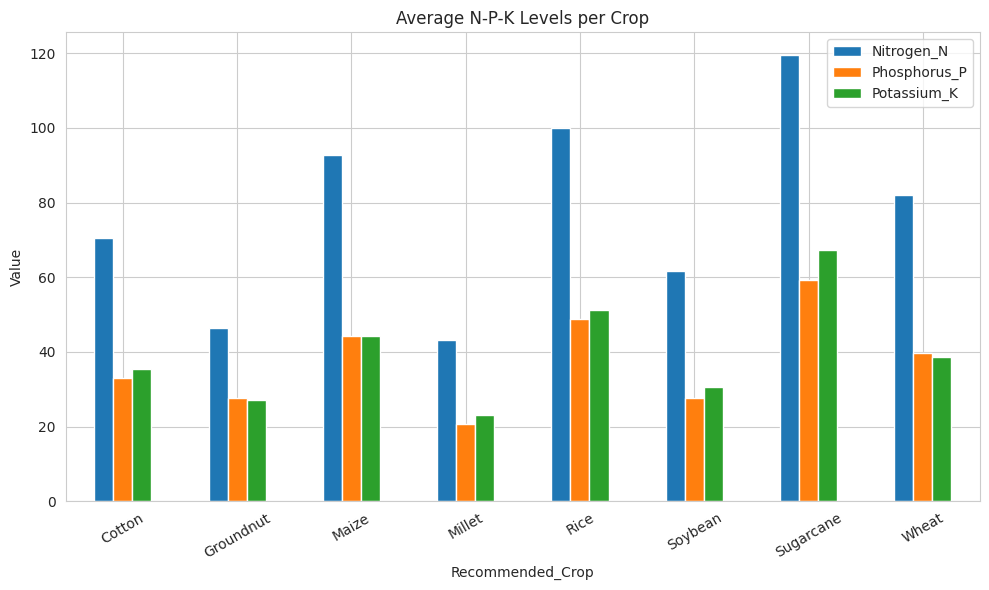

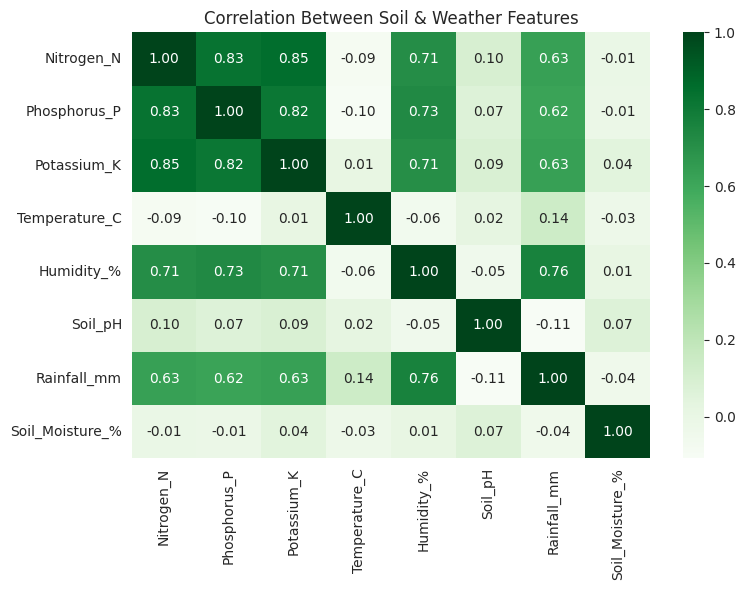


STEP 8: MACHINE LEARNING
Model accuracy: 83.33%


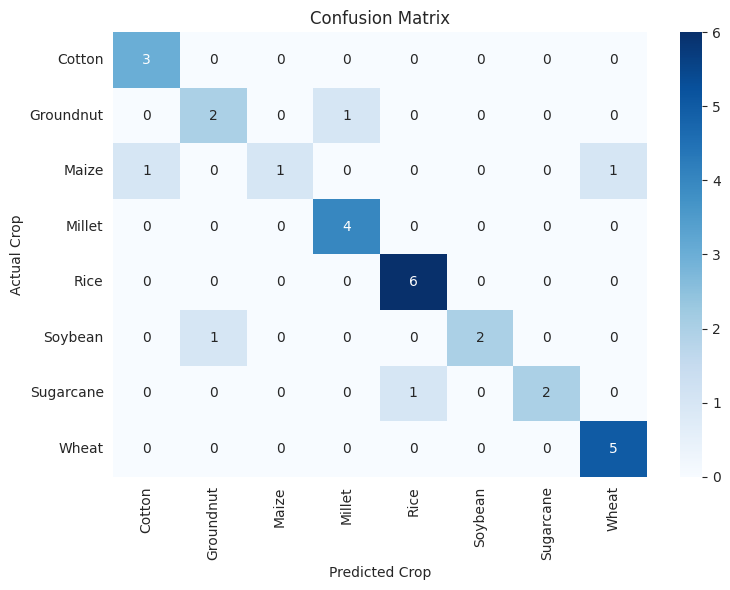


STEP 9: WEB SCRAPING
Fetching latest version info for the Python libraries used in this project...

pandas          -> pandas 3.0.6
numpy           -> numpy 2.5.3
scikit-learn    -> scikit-learn 1.9.1
matplotlib      -> matplotlib 3.11.2
scipy           -> scipy 1.18.1

STEP 10: CRUD OPERATIONS (Create / Read / Update / Delete)

READ (first 3 records):
{'Field_ID': 'F001', 'Nitrogen_N': 49, 'Phosphorus_P': 32, 'Potassium_K': 34, 'Temperature_C': 29.3, 'Humidity_%': 62.0, 'Soil_pH': 6.19, 'Rainfall_mm': 79.4, 'Soil_Moisture_%': 23.5, 'Recommended_Crop': 'Groundnut', 'Crop_Label': 1}
{'Field_ID': 'F002', 'Nitrogen_N': 50, 'Phosphorus_P': 18, 'Potassium_K': 22, 'Temperature_C': 32.1, 'Humidity_%': 30.5, 'Soil_pH': 6.95, 'Rainfall_mm': 81.6, 'Soil_Moisture_%': 32.7, 'Recommended_Crop': 'Millet', 'Crop_Label': 3}
{'Field_ID': 'F003', 'Nitrogen_N': 50, 'Phosphorus_P': 15, 'Potassium_K': 26, 'Temperature_C': 31.1, 'Humidity_%': 30.2, 'Soil_pH': 5.53, 'Rainfall_mm': 66.2, 'Soil_Moisture_%': 4

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pa_utils

sns.set_style("whitegrid")


feature_columns = ["Nitrogen_N", "Phosphorus_P", "Potassium_K", "Temperature_C",
                    "Humidity_%", "Soil_pH", "Rainfall_mm", "Soil_Moisture_%"]   # LIST

crop_set = set()          # SET  -> will hold unique crop names (no duplicates)
crop_avg_dict = {}        # DICT -> crop name -> average nitrogen (filled later)


DATA_PATH = "precision_agriculture_data.csv"

print("=" * 60)
print("STEP 1: DATA COLLECTION")
print("=" * 60)

try:
    df = pd.read_csv(DATA_PATH)
    pa_utils.log_message(f"Loaded {len(df)} rows from {DATA_PATH}")
    print(f"Dataset shape: {df.shape[0]} fields, {df.shape[1]} columns")
except FileNotFoundError:
    print(f"ERROR: '{DATA_PATH}' not found. Upload the CSV first.")
    raise


print("\n" + "=" * 60)
print("STEP 2: DATA PREPROCESSING")
print("=" * 60)

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = pa_utils.clean_numeric_column(df[col])   # uses custom module function

df = df.drop_duplicates()

label_encoder = LabelEncoder()
df["Crop_Label"] = label_encoder.fit_transform(df["Recommended_Crop"])

crop_set = set(df["Recommended_Crop"])   # B. Data Structures: SET of unique crops
print("Unique crops (set):", crop_set)


print("\n" + "=" * 60)
print("STEP 3: STATISTICAL ANALYSIS")
print("=" * 60)

nitrogen_stats = pa_utils.summarize_column(df["Nitrogen_N"])   # dict: mean/median/std/variance
print("Nitrogen statistics:", nitrogen_stats)

n_min, n_max = pa_utils.get_min_max(df["Rainfall_mm"])   # tuple unpacking
print(f"Rainfall range: {n_min} mm to {n_max} mm")

for crop in crop_set:
    crop_avg_dict[crop] = round(df[df["Recommended_Crop"] == crop]["Nitrogen_N"].mean(), 2)
print("Average nitrogen per crop (dict):", crop_avg_dict)


print("\n" + "=" * 60)
print("STEP 4: PROBABILITY")
print("=" * 60)

for crop in sorted(crop_set):
    p = pa_utils.probability_of_crop(df, crop)
    print(f"P({crop}) = {p}  ->  {p*100:.2f}% of fields recommend this crop")


print("\n" + "=" * 60)
print("STEP 5: SAMPLING & INFERENCE")
print("=" * 60)

sample = df["Nitrogen_N"].sample(n=30, random_state=1)   # random sample of 30 fields
sample_mean = sample.mean()
population_mean = df["Nitrogen_N"].mean()

print(f"Population mean nitrogen: {population_mean:.2f}")
print(f"Sample mean nitrogen (n=30): {sample_mean:.2f}")

# 95% confidence interval for the sample mean
confidence = 0.95
sem = stats.sem(sample)                       # standard error of the mean
ci = stats.t.interval(confidence, len(sample) - 1, loc=sample_mean, scale=sem)
print(f"95% Confidence Interval for sample mean: ({ci[0]:.2f}, {ci[1]:.2f})")


print("\n" + "=" * 60)
print("STEP 6: HYPOTHESIS TESTING")
print("=" * 60)

rice_rainfall = df[df["Recommended_Crop"] == "Rice"]["Rainfall_mm"]
wheat_rainfall = df[df["Recommended_Crop"] == "Wheat"]["Rainfall_mm"]

# H0: mean rainfall is the same for Rice and Wheat fields
# H1: mean rainfall is significantly different
t_stat, p_value = stats.ttest_ind(rice_rainfall, wheat_rainfall)
print(f"T-statistic = {t_stat:.3f},  P-value = {p_value:.5f}")

if p_value < 0.05:
    print("Result: Reject H0 -> Rice and Wheat fields have significantly different rainfall.")
else:
    print("Result: Fail to reject H0 -> No significant rainfall difference detected.")


print("\n" + "=" * 60)
print("STEP 7: DATA VISUALIZATION")
print("=" * 60)

npk_avg = df.groupby("Recommended_Crop")[["Nitrogen_N", "Phosphorus_P", "Potassium_K"]].mean()
npk_avg.plot(kind="bar", figsize=(10, 6), color=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.title("Average N-P-K Levels per Crop")
plt.xlabel("Recommended_Crop")
plt.ylabel("Value")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()          # displays inline instead of saving to a file

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="Greens", fmt=".2f")
plt.title("Correlation Between Soil & Weather Features")
plt.tight_layout()
plt.show()


print("\n" + "=" * 60)
print("STEP 8: MACHINE LEARNING")
print("=" * 60)

X = df[feature_columns]
y = df["Crop_Label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # I. NumPy array operations happen here internally

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"Model accuracy: {acc:.2%}")

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.tight_layout()
plt.show()


def recommend_crop(nitrogen, phosphorus, potassium, temperature,
                    humidity, soil_ph, rainfall, soil_moisture):
    """A. Function demonstrating core Python concepts (params, return values)."""
    try:
        new_data = pd.DataFrame([{
            "Nitrogen_N": nitrogen, "Phosphorus_P": phosphorus, "Potassium_K": potassium,
            "Temperature_C": temperature, "Humidity_%": humidity, "Soil_pH": soil_ph,
            "Rainfall_mm": rainfall, "Soil_Moisture_%": soil_moisture,
        }])[feature_columns]
        new_scaled = scaler.transform(new_data)
        pred_label = model.predict(new_scaled)[0]
        pred_crop = label_encoder.inverse_transform([pred_label])[0]
        confidence = model.predict_proba(new_scaled)[0][pred_label]
        return pred_crop, confidence
    except Exception as e:
        print(f"Prediction failed: {e}")
        return None, None


print("\n" + "=" * 60)
print("STEP 9: WEB SCRAPING")
print("=" * 60)
print("Fetching latest version info for the Python libraries used in this project...\n")

libraries = ["pandas", "numpy", "scikit-learn", "matplotlib", "scipy"]   # LIST

for lib in libraries:
    try:
        url = f"https://pypi.org/project/{lib}/"
        response = requests.get(url, timeout=10)
        soup = BeautifulSoup(response.text, "html.parser")
        title_tag = soup.find("h1")
        info = title_tag.get_text(strip=True) if title_tag else "Not found"
        print(f"{lib:15s} -> {info}")
    except requests.exceptions.RequestException as e:
        print(f"{lib:15s} -> Could not fetch (no internet or site changed): {e}")


print("\n" + "=" * 60)
print("STEP 10: CRUD OPERATIONS (Create / Read / Update / Delete)")
print("=" * 60)

records = df.to_dict(orient="records")   # list of dicts -> easy CRUD in memory


def create_record(new_record):
    records.append(new_record)
    print("Record added.")


def read_records(limit=5):
    for r in records[:limit]:
        print(r)


def update_record(field_id, new_crop):
    for r in records:
        if r.get("Field_ID") == field_id:
            r["Recommended_Crop"] = new_crop
            print(f"Updated {field_id} -> {new_crop}")
            return
    print(f"{field_id} not found.")


def delete_record(field_id):
    global records
    before = len(records)
    records = [r for r in records if r.get("Field_ID") != field_id]
    if len(records) < before:
        print(f"Deleted {field_id}.")
    else:
        print(f"{field_id} not found.")


print("\nREAD (first 3 records):")
read_records(3)

print("\nCREATE new record:")
create_record({
    "Field_ID": "F999", "Nitrogen_N": 95, "Phosphorus_P": 45, "Potassium_K": 40,
    "Temperature_C": 27.0, "Humidity_%": 75.0, "Soil_pH": 6.5,
    "Rainfall_mm": 210.0, "Soil_Moisture_%": 46.0, "Recommended_Crop": "Rice"
})

print("\nUPDATE record F001:")
update_record("F001", "Wheat")

print("\nDELETE record F002:")
delete_record("F002")

print(f"\nTotal records after CRUD operations: {len(records)}")


def run_menu():
    """A. Demonstrates loops + conditionals + functions together."""
    while True:
        print("\n--- Precision Agriculture Menu ---")
        print("1. Read records\n2. Add record\n3. Update crop\n4. Delete record\n5. Exit")
        choice = input("Enter choice (1-5): ")

        if choice == "1":
            read_records(5)
        elif choice == "2":
            print("(Add your own input prompts here for a real record)")
        elif choice == "3":
            fid = input("Field ID to update: ")
            new_crop = input("New crop: ")
            update_record(fid, new_crop)
        elif choice == "4":
            fid = input("Field ID to delete: ")
            delete_record(fid)
        elif choice == "5":
            print("Exiting.")
            break
        else:
            print("Invalid choice, try again.")

print("\n" + "=" * 60)
print("STEP 11: CROP RECOMMENDATION")
print("=" * 60)

print("\nEnter field values:")

nitrogen = float(input("Nitrogen (N): "))
phosphorus = float(input("Phosphorus (P): "))
potassium = float(input("Potassium (K): "))
temperature = float(input("Temperature (°C): "))
humidity = float(input("Humidity (%): "))
soil_ph = float(input("Soil pH: "))
rainfall = float(input("Rainfall (mm): "))
soil_moisture = float(input("Soil Moisture (%): "))

crop, confidence = recommend_crop(
    nitrogen=nitrogen,
    phosphorus=phosphorus,
    potassium=potassium,
    temperature=temperature,
    humidity=humidity,
    soil_ph=soil_ph,
    rainfall=rainfall,
    soil_moisture=soil_moisture
)

print(f"\nRecommended crop: {crop}")
print(f"Confidence: {confidence:.1%}")

pa_utils.log_message(
    f"Final recommendation for input: {crop} ({confidence:.1%})"
)

print("\nAll steps complete. Log written to project_log.txt")